In [2]:
from pydantic import BaseModel, Field
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from operator import add
from typing import Any, Annotated, Dict, List

from langchain_core.messages import BaseMessage, AIMessage, ToolMessage, HumanMessage, SystemMessage
from langchain_core.tools import BaseTool
from langchain_core.prompts import BasePromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.prompts import StringPromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langchain_protocol import Literal

from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document,Prefetch, FusionQuery
from qdrant_client import models

import instructor
from langsmith import traceable, get_current_run_tree

import pandas as pd
import openai
import fastembed

from jinja2 import Template
from typing import List, Dict, Any, Optional, Union
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json
import os
import importlib
import utils
from dotenv import load_dotenv

load_dotenv()
importlib.reload(utils)

from utils import format_ai_message, parse_function_definition, get_type_from_annotation, parse_docstring_params, get_tool_descriptions

In [3]:
load_dotenv()

# Retrieve API keys from environment variables
openai_api_key = os.getenv('OPENAI_API_KEY')
google_api_key = os.getenv('GEMINI_API_KEY')
qdrant_url = os.getenv('QDRANT_URL')
qdrant_api_key = os.getenv('QDRANT_API_KEY')
langsmith_api_key = os.getenv('LANGSMITH_API_KEY')
if qdrant_url and "qdrant:6333" in qdrant_url:
    # Docker service host is not resolvable from a local notebook kernel
    qdrant_url = qdrant_url.replace("qdrant:6333", "localhost:6333")

# Verify keys are loaded
print(f"OpenAI API Key present: {bool(openai_api_key)}")
print(f"Google API Key present: {bool(google_api_key)}")
print(f"Qdrant URL present: {bool(qdrant_url)}")
print(f"Qdrant API Key present: {bool(qdrant_api_key)}")
print(f"Langsmith API Key present: {bool(langsmith_api_key)}")

qdrant_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_api_key,
)

OpenAI API Key present: True
Google API Key present: False
Qdrant URL present: True
Qdrant API Key present: False
Langsmith API Key present: True


/var/folders/pw/cff5mdz55nb7ghs1f4rh8f9r0000gn/T/ipykernel_97807/4105341488.py:20: UserWarning: Api key is used with an insecure connection.
  qdrant_client = QdrantClient(


In [4]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding

In [5]:
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

In [6]:
query = "Can I get a Tablet?"

In [8]:
answer = retrieve_data(query, qdrant_client, top_k=5)

In [9]:
answer

{'retrieved_context_ids': ['B09S6THZJ1',
  'B07K89WHJH',
  'B07GXM524L',
  'B08DXTHKQ7',
  'B00JQN5ZAM'],
 'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes with a custom-designed senior friendly interface, applications, unlimited 24/7/365 customer support, free companion applications for Android and iOS (for other family members), a private network to share & connect with your loved ones. Designed to be used by people above 75 years of age with ease.', '4G LTE CONNECTED TABLET: This tablet is ideal for connecting to your aging loved ones, sin

Multi Intent Questions

In [10]:
query = "Can I get a Tablet for my kid, a watch for me and a laptop for my wife?"

In [15]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [16]:
def query_expand_node(query) -> dict:
    prompt_template = f"""You are part of a shopping assistant that can answer questions about the product in stock.
    Instructions:
    - You will be given a question, and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
    - The statements should not overlap in context
    <Question>
    {{query}}
    </Question>
    """
    
    template = Template(prompt_template)
    prompt = template.render(query=query)

    client = instructor.from_openai(OpenAI())
    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role":"system", "content": prompt}],
        temperature=0.7,
    )

    return {
        "queries": response.statements
    }

In [17]:
answer

{'retrieved_context_ids': ['B09S6THZJ1',
  'B07K89WHJH',
  'B07GXM524L',
  'B08DXTHKQ7',
  'B00JQN5ZAM'],
 'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes with a custom-designed senior friendly interface, applications, unlimited 24/7/365 customer support, free companion applications for Android and iOS (for other family members), a private network to share & connect with your loved ones. Designed to be used by people above 75 years of age with ease.', '4G LTE CONNECTED TABLET: This tablet is ideal for connecting to your aging loved ones, sin

### LangGraph 
Query Expansion (Sequential Execution)

In [18]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

Query Expansion/Rewriting Node

In [19]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [24]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:
    prompt_template = f"""You are part of a shopping assistant that can answer questions about the products in stock.
    Instructions:
    - You will be given a question, and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
    - The statements should not overlap in context
    <Question>
    {{query}}
    </Question>
    """
    
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)

    client = instructor.from_openai(OpenAI())
    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role":"system", "content": prompt}],
        temperature=0.7,
    )

    return {
        "queries": response.expanded_query
    }

Retriever Node

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import FieldCondition, Filter, MatchValue,VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document,Prefetch, FusionQuery
from qdrant_client import models

import instructor
from langsmith import traceable, get_current_run_tree
import openai
from pydantic import BaseModel, Field
import numpy as np
import os
from dotenv import load_dotenv

from api.utils.prompt_managements import prompt_template_config, prompt_template_registry

# Load environment variables from .env file
load_dotenv()

# Retrieve API keys from environment variables
openai_api_key = os.getenv('OPENAI_API_KEY')
google_api_key = os.getenv('GEMINI_API_KEY')
qdrant_url = os.getenv('QDRANT_URL')
qdrant_api_key = os.getenv('QDRANT_API_KEY')
langsmith_api_key = os.getenv('LANGSMITH_API_KEY')
if qdrant_url and "qdrant:6333" in qdrant_url:
    # Docker service host is not resolvable from a local notebook kernel
    qdrant_url = qdrant_url.replace("qdrant:6333", "localhost:6333")

# Verify keys are loaded
print(f"OpenAI API Key present: {bool(openai_api_key)}")
print(f"Google API Key present: {bool(google_api_key)}")
print(f"Qdrant URL present: {bool(qdrant_url)}")
print(f"Qdrant API Key present: {bool(qdrant_api_key)}")
print(f"Langsmith API Key present: {bool(langsmith_api_key)}")

qdrant_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_api_key,
)

# qdrant_client.create_collection(
#     collection_name="Amazon_Electronics_Products",
#     vectors_config={
#         "text-embedding-3-small": VectorParams(
#             size=1536,
#             distance=Distance.COSINE
#         )
#     },
#     sparse_vectors_config={
#         "bm25": SparseVectorParams(
#             modifier=models.Modifier.IDF
#         )
#     }
# )

# qdrant_client.create_payload_index(
#     collection_name="Amazon_Electronics_Products",
#     field_name="store",
#     field_schema=PayloadSchemaType.KEYWORD
# )

client = instructor.from_openai(openai.OpenAI())

class RagGenerationResponse(BaseModel):
    answer: str = Field(description="The answer to the question")
    reasoning: str = Field(description="The reasoning behind the answer")

class RAGUsedContext(BaseModel):
    id: str | int = Field(description="The ID of the retrieved review")
    review: str = Field(description="The text of the retrieved review")
    title: str | None = Field(default=None, description="The product title")
    description: str | list[str] | None = Field(default=None, description="The product description")
    categories: list[str] = Field(default_factory=list, description="The product categories")
    images: list[dict] = Field(default_factory=list, description="The product image variants")
    videos: list[dict] = Field(default_factory=list, description="The product videos")
    features: list[str] = Field(default_factory=list, description="The product feature bullets")
    main_category: str | None = Field(default=None, description="The product main category")
    store: str | None = Field(default=None, description="The store or brand")
    price: float | None = Field(default=None, description="The product price")
    rating_number: int | None = Field(default=None, description="The product rating count")
    details: dict | None = Field(default=None, description="The product details map")

class RagGenerationResponseReference(BaseModel):
    answer: str = Field(description="The answer to the question")
    reasoning: str = Field(description="The reasoning behind the answer")
    used_context: list[RAGUsedContext] = Field(description="The list of retrieved reviews used to generate the answer")
    references: list[RAGUsedContext] = Field(description="The list of references used to generate the answer")

@traceable(
        name="get_embedding",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    # Safely extract usage metadata whether response is an object or dict
    usage_obj = getattr(response, "usage", None)
    if usage_obj is None and isinstance(response, dict):
        usage_obj = response.get("usage")

    if current_run and usage_obj:
        try:
            input_tokens = getattr(usage_obj, "prompt_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("prompt_tokens")
            total_tokens = getattr(usage_obj, "total_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("total_tokens")
            current_run.add_metadata({
                "usage_metadata": {
                    "input_tokens": input_tokens,
                    "total_tokens": total_tokens,
                    "embedding_model": model,
                }
            })
        except Exception:
            # Fallback: ignore metadata errors to avoid breaking embedding
            logger = __import__("logging").getLogger(__name__)
            logger.debug("Failed to add embedding usage metadata to run")
    return response.data[0].embedding

@traceable(
        name="get_embeddings_batch",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embeddings_batch(text_list, model= "text-embedding-3-small", batch_size=100):
    if(len(text_list) <= batch_size):
        response = openai.embeddings.create(input=text_list, model=model)
        return [embedding.embedding for embedding in response.data]
    all_embeddings = []
    counter = 1
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        response = openai.embeddings.create(input=batch, model=model)
        all_embeddings.extend([embedding.embedding for embedding in response.data])
        print(f"Processed batch {counter} / {len(text_list) // batch_size + 1}")
        counter += 1
    return all_embeddings

@traceable(
        name="retrieve_data",
        tags=["retrieval", "qdrant"],
        run_type="retriever"
)
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

@traceable(
        name="process_context",
        tags=["context_processing"],
        run_type="prompt"
)

def process_context(retrieve_context):
    preprocessed_context = ""
    for idx, context in enumerate(retrieve_context["retrieved_contexts"]):
        preprocessed_context += f"Product {idx+1}:\n{context}\n\n"
    return preprocessed_context

@traceable(
        name="build_prompt",
        tags=["prompt_construction"],
        run_type="prompt"
)
def build_prompt(preprocessed_context, question):
    template = prompt_template_config("api/prompts/retrieval_generation.yaml", "retrieval_generation_prompt")
    return template.render(preprocessed_context=preprocessed_context, question=question)

@traceable(
        name="gen_answer",
        tags=["answer_generation", "openai"],
        run_type="llm",
        metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def gen_answer(prompt):
    # Call may return different shapes depending on client used (OpenAI SDK or a helper
    # that returns a Pydantic model). Handle both cases and normalize to a dict.
    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        response_model=RagGenerationResponse,
    )

    # Some clients return a tuple (model_obj, raw_response) or list; handle that.
    raw_resp = None
    if isinstance(response, (tuple, list)):
        if len(response) == 2:
            response, raw_resp = response
        else:
            response = response[0]

    # Normalize into a consistent gen_response dict
    gen_response = {
        "text": None,
        "usage": None,
        "model": None,
        "raw_response": raw_resp or response,
    }

    # If the client returned a Pydantic model (e.g., RagGenerationResponse), extract fields
    if isinstance(response, BaseModel):
        # pydantic v1/v2 compatibility: try attribute access first
        text_val = getattr(response, "answer", None) or getattr(response, "text", None)
        if text_val is None:
            # fall back to model_dump if available
            try:
                dumped = response.model_dump() if hasattr(response, "model_dump") else response.dict()
                text_val = dumped.get("answer") or dumped.get("text")
            except Exception:
                text_val = str(response)
        gen_response.update({
            "text": text_val,
            "usage": None,
            "model": getattr(response, "model", None) or None,
        })
    else:
        # Assume OpenAI-style response (has choices and usage)
        try:
            gen_text = response.choices[0].message.content
        except Exception:
            # Last-resort stringification
            try:
                # If raw_resp contains the OpenAI-style object, try there
                gen_text = raw_resp.choices[0].message.content if raw_resp is not None else str(response)
            except Exception:
                gen_text = str(response)

        # Safely extract usage from either the primary response or the raw response
        usage_source = getattr(response, "usage", None) or (getattr(raw_resp, "usage", None) if raw_resp is not None else None)
        if usage_source is None and isinstance(raw_resp, dict):
            usage_source = raw_resp.get("usage")

        def _get_token(u, name):
            if u is None:
                return None
            if hasattr(u, name):
                return getattr(u, name)
            if isinstance(u, dict):
                return u.get(name)
            return None

        gen_response.update({
            "text": gen_text,
            "usage": {
                "prompt_tokens": _get_token(usage_source, "prompt_tokens"),
                "completion_tokens": _get_token(usage_source, "completion_tokens"),
                "total_tokens": _get_token(usage_source, "total_tokens"),
            },
            "model": getattr(response, "model", None) or (getattr(raw_resp, "model", None) if raw_resp is not None else "gpt-4.1-mini"),
        })

    current_run = get_current_run_tree()
    if current_run and gen_response.get("usage"):
        try:
            current_run.add_metadata({
                "usage_metadata": gen_response["usage"]
            })
        except Exception:
            logger = __import__("logging").getLogger(__name__)
            logger.debug("Failed to add generation usage metadata to run")

    return gen_response, gen_response.get("raw_response")

@traceable(
        name="rag_pipeline",
        tags=["pipeline", "retrieval_generation"],
)
def rag_pipeline(question, qdrant_client, top_k=5):
    retrieve_context = retrieve_data(question, qdrant_client=qdrant_client, top_k=top_k)
    preprocessed_context = process_context(retrieve_context)
    prompt = build_prompt(preprocessed_context, question)
    gen, raw_gen = gen_answer(prompt)

    # Normalize final answer whether gen is dict-like or an object
    if isinstance(gen, dict):
        answer_text = gen.get("text") or gen.get("answer") or str(gen)
        rag_generation_response = gen
    else:
        answer_text = getattr(gen, "answer", getattr(gen, "text", str(gen)))
        # try to convert to dict if pydantic object provides model_dump
        try:
            rag_generation_response = gen.model_dump() if hasattr(gen, "model_dump") else gen.dict()
        except Exception:
            rag_generation_response = str(gen)

    final_result = {
        "question": question,
        "original_output": answer_text,
        "raw_gen": raw_gen,
        "answer": answer_text.answer if isinstance(answer_text, RagGenerationResponse) else answer_text,
        "references": answer_text.references if isinstance(answer_text, RagGenerationResponseReference) else [],
        "retrieved_context_ids": retrieve_context['retrieved_context_ids'],
        "retrieved_context": retrieve_context,
        "similarity_scores": retrieve_context['similarity_scores'],
        "rag_generation_response": rag_generation_response,
    }

    return final_result

def rag_pipeline_wrapper(question, qdrant_client, top_k=5):
    pipeline_result = rag_pipeline(question, qdrant_client, top_k)
    used_context = []

    retrieved_context = pipeline_result.get("retrieved_context", {})

    if isinstance(retrieved_context, dict):
        retrieved_context_ids = retrieved_context.get("retrieved_context_ids", [])
        retrieved_contexts = retrieved_context.get("retrieved_contexts", [])
        similarity_scores = retrieved_context.get("similarity_scores", [])
        retrieved_context_ratings = retrieved_context.get("retrieved_context_ratings", [])
        retrieved_context_prices = retrieved_context.get("retrieved_context_prices", [])
        retrieved_context_images = retrieved_context.get("retrieved_context_images", [])
        retrieved_context_rating_numbers = retrieved_context.get("retrieved_context_rating_numbers", [])

        item_count = len(retrieved_context_ids)
        for index in range(item_count):
            review = retrieved_contexts[index] if index < len(retrieved_contexts) else ""
            images = retrieved_context_images[index] if index < len(retrieved_context_images) else []
            image_list = []
            if isinstance(images, list):
                for image in images:
                    if isinstance(image, dict):
                        image_list.append(image)
                    elif isinstance(image, str) and image:
                        image_list.append({"large": image, "thumb": image, "hi_res": image})
            elif isinstance(images, str) and images:
                image_list.append({"large": images, "thumb": images, "hi_res": images})

            used_context.append({
                "id": retrieved_context_ids[index],
                "review": review,
                "title": review[:80] if review else str(retrieved_context_ids[index]),
                "description": review,
                "images": image_list,
                "videos": [],
                "features": [],
                "categories": [],
                "main_category": "",
                "store": "",
                "price": retrieved_context_prices[index] if index < len(retrieved_context_prices) else None,
                "rating_number": retrieved_context_rating_numbers[index] if index < len(retrieved_context_rating_numbers) else None,
                "score": similarity_scores[index] if index < len(similarity_scores) else None,
                "average_rating": retrieved_context_ratings[index] if index < len(retrieved_context_ratings) else None,
                "details": {},
            })

    return {
        "answer": pipeline_result.get("answer"),
        "used_context": used_context,
        "retrieved_context_ids": pipeline_result.get("retrieved_context_ids"),
        "similarity_scores": pipeline_result.get("similarity_scores"),
    }
       


Retriever Node

In [36]:
@traceable(
        name="get_embedding",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    # Safely extract usage metadata whether response is an object or dict
    usage_obj = getattr(response, "usage", None)
    if usage_obj is None and isinstance(response, dict):
        usage_obj = response.get("usage")

    if current_run and usage_obj:
        try:
            input_tokens = getattr(usage_obj, "prompt_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("prompt_tokens")
            total_tokens = getattr(usage_obj, "total_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("total_tokens")
            current_run.add_metadata({
                "usage_metadata": {
                    "input_tokens": input_tokens,
                    "total_tokens": total_tokens,
                    "embedding_model": model,
                }
            })
        except Exception:
            # Fallback: ignore metadata errors to avoid breaking embedding
            logger = __import__("logging").getLogger(__name__)
            logger.debug("Failed to add embedding usage metadata to run")
    return response.data[0].embedding

@traceable(
        name="get_embeddings_batch",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embeddings_batch(text_list, model= "text-embedding-3-small", batch_size=100):
    if(len(text_list) <= batch_size):
        response = openai.embeddings.create(input=text_list, model=model)
        return [embedding.embedding for embedding in response.data]
    all_embeddings = []
    counter = 1
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        response = openai.embeddings.create(input=batch, model=model)
        all_embeddings.extend([embedding.embedding for embedding in response.data])
        print(f"Processed batch {counter} / {len(text_list) // batch_size + 1}")
        counter += 1
    return all_embeddings

@traceable(
        name="retrieve_data",
        tags=["retrieval", "qdrant"],
        run_type="retriever"
)
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

In [42]:
@traceable(
    name="retrieve_node",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node(state:State) -> dict:
    retrieved_context = []
    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client=qdrant_client, top_k=5))
    return {
        "retrieved_context": retrieved_context
    }

Aggregator Node

In [27]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question based on the retrieved contexts")

In [40]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"},
    tags=["aggregation", "openai"]
)
def aggregator_node(state: State) -> dict:
    preproccesed_context = "\n".join(state.retrieved_context)

    prompt_template = f"""You are part of a shopping assistant that can answer questions about the products in stock.
    Instructions:
    - You will be given a question, and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
    - The statements should not overlap in context

    Instructions:
    - You need to answer the question based on the provided context only
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detialed specification in bullet points.

    Context:
    {{preproccesed_context}}

    <Question>
    {{query}}
    </Question>
    """
    
    template = Template(prompt_template)
    prompt = template.render(preproccesed_context=preproccesed_context, query=state.initial_query)

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role":"system", "content": prompt}],
        temperature=0.7,
    )

    return {
        "expanded_query": response.answer
    }

In [46]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)


graph = workflow.compile()

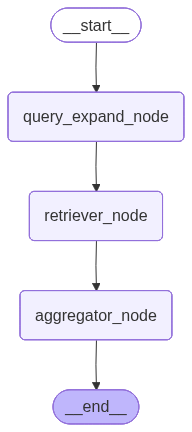

In [47]:
display(Image(graph.get_graph().draw_mermaid_png()))